In [1]:
# SUPPORT IMPORTS
import os
import json
import pickle
import warnings
import torch

# DATA ANALYSIS IMPORTS
import numpy as np
import pandas as pd

# NLP & MODEL IMPORTS
import nltk
import faiss
from nltk.corpus import wordnet as wn
from transformers import AutoTokenizer, AutoModelForTokenClassification, AutoModel
from transformers import Pipeline, DataCollatorForTokenClassification
from sentence_transformers import SentenceTransformer, CrossEncoder

# EVALUATION
import evaluate

In [2]:
# SETTINGS
warnings.filterwarnings('ignore')

In [3]:
# WORDNET INSTALLATION
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# SYSTEM CONSTANTS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_MODEL = "dslim/bert-base-NER"
REFINED_MODEL = "bert-base-cased"
RETRIEVER_MODEL = "all-MiniLM-L6-v2"
CROSS_ENCODER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
CONFIDENCE_THRESHOLD = 0.45
TOP_K_RETRIEVAL = 5
MAX_LENGTH = 128
METRIC = evaluate.load("seqeval")

# PATHS FOR CHECKPOINTING
STATE_FILE = "pipeline_state.pkl"
KB_INDEX_PATH = "knowledge_base.index"

In [5]:
import os
import pickle
from datasets import load_dataset
from tqdm import tqdm

os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "600"
if os.path.exists("kb_sentences.pkl"):
    print("Loading cached KB sentences...")
    with open("kb_sentences.pkl", "rb") as f:
        KB_SENTENCES = pickle.load(f)

else:
    print("LOADING THE CORPSE...")
    print("OOH! SORRY LOADING THE CORPUS...")

    wiki_dataset = load_dataset(
        "wikimedia/wikipedia",
        "20231101.en",
        split="train",
        streaming=True
    )

    KB_SENTENCES = []
    target = 50000
    batch_size = 1000

    iterator = iter(wiki_dataset)
    pbar = tqdm(total=target)

    while len(KB_SENTENCES) < target:
        batch = []
        for _ in range(batch_size):
            try:
                batch.append(next(iterator))
            except StopIteration:
                break

        for item in batch:
            try:
                text = item["text"].replace("\n", " ")
                if len(text) > 100:
                    KB_SENTENCES.append(text[:512])
                    pbar.update(1)
                    if len(KB_SENTENCES) >= target:
                        break
            except Exception:
                continue

    pbar.close()

    print("Saving KB sentences cache...")
    with open("kb_sentences.pkl", "wb") as f:
        pickle.dump(KB_SENTENCES, f)

print("Total KB passages:", len(KB_SENTENCES))

Loading cached KB sentences...
Total KB passages: 50000


In [ ]:
class RA_NER_SYSTEM:
    def __init__(self, NER_MODEL_PATH, RETRIEVER, CROSS_ENC):
        self.TOKENIZER = AutoTokenizer.from_pretrained(NER_MODEL_PATH)
        self.MODEL = AutoModelForTokenClassification.from_pretrained(NER_MODEL_PATH).to(DEVICE)
        self.RETRIEVER = RETRIEVER
        self.CROSS_ENCODER = CROSS_ENC

    def GET_INITIAL_PREDICTIONS(self, SENTENCE):
        inputs = self.TOKENIZER(
            SENTENCE,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH
        ).to(DEVICE)
        with torch.no_grad():
            outputs = self.MODEL(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        conf, preds = torch.max(probs, dim=-1)
        tokens = self.TOKENIZER.convert_ids_to_tokens(inputs["input_ids"][0])
        return conf, preds, tokens, inputs

    def EXPAND_ENTITY(self, span_text):
        EXPANSIONS = set()
        for syn in wn.synsets(span_text):
            for lemma in syn.lemmas():
                EXPANSIONS.add(lemma.name().replace("_", " "))
            for hyper in syn.hypernyms():
                EXPANSIONS.update([l.name().replace("_", " ") for l in hyper.lemmas()])
            for hypo in syn.hyponyms():
                EXPANSIONS.update([l.name().replace("_", " ") for l in hypo.lemmas()])
        return list(EXPANSIONS)[:10]

    def ENRICH_SPAN(self, span_text, context):
        query = f"{span_text} in context: {context}"

        results = self.RETRIEVER.QUERY(query, K=TOP_K_RETRIEVAL)

        if not results:
            return None

        pairs = [[query, r] for r in results]
        scores = self.CROSS_ENCODER.predict(pairs)

        best_idx = int(np.argmax(scores))
        if scores[best_idx] < 0.4:
            return None

        return self.FORMAT_KNOWLEDGE(results[best_idx])

    def APPLY_ENTITY_SCALING(self, hidden_states, entity_mask):
        d = hidden_states.size(-1)
        scale = 1 / torch.sqrt(torch.tensor(d, dtype=torch.float32, device=hidden_states.device))

        entity_mask = entity_mask.to(hidden_states.device).unsqueeze(-1)

        scaled = hidden_states * scale
        scaled = scaled * (1 + entity_mask)

        return scaled

    def BUILD_ENRICHED_INPUT(self, sentence):
        conf, preds, tokens, inputs = self.GET_INITIAL_PREDICTIONS(sentence)

        pred_ids = preds[0].detach().cpu().numpy().tolist()
        conf_vals = conf[0].cpu().numpy().tolist()

        spans = []
        current = []

        for tok, pid, c in zip(tokens, pred_ids, conf_vals):
            label = self.MODEL.config.id2label[pid]

            if tok in ["[CLS]", "[SEP]", "[PAD]"]:
                continue

            if label.startswith("B-"):
                if current:
                    spans.append(current)
                current = [(tok, label, c)]
            elif label.startswith("I-") and current:
                current.append((tok, label, c))
            else:
                if current:
                    spans.append(current)
                    current = []

        if current:
            spans.append(current)

        enriched_chunks = [sentence]
        entity_mask = torch.zeros(MAX_LENGTH)

        for span in spans:
            span_text = ""
            span_conf = []

            for tok, _, c in span:
                if tok.startswith("##"):
                    span_text += tok[2:]
                else:
                    span_text += " " + tok
                span_conf.append(c)

            span_text = span_text.strip()
            avg_conf = float(np.mean(span_conf))

            if avg_conf < CONFIDENCE_THRESHOLD:
                knowledge = self.ENRICH_SPAN(span_text, sentence)
                if knowledge:
                    enriched_chunks.append(knowledge)

        enriched_text = " ".join(enriched_chunks)

        return enriched_text, entity_mask

    def REFINED_INFERENCE(self, sentence):
        enriched_text, entity_mask = self.BUILD_ENRICHED_INPUT(sentence)

        inputs = self.TOKENIZER(
            enriched_text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH
        ).to(DEVICE)

        with torch.no_grad():
            outputs = self.MODEL.base_model(**inputs)
            hidden_states = outputs.last_hidden_state

        # hidden_states = self.APPLY_ENTITY_SCALING(hidden_states, entity_mask)

        logits = self.MODEL.classifier(hidden_states)

        probs = torch.softmax(logits, dim=-1)
        conf, preds = torch.max(probs, dim=-1)

        return conf, preds

    def FORMAT_KNOWLEDGE(self, text):
        return f"[KNOWLEDGE] {text} [/KNOWLEDGE]"

def COMPUTE_METRICS(true_labels, pred_labels):
    results = METRIC.compute(predictions=pred_labels, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

def RUN_BASELINE(system, dataset):
    all_preds, all_labels = [], []

    for sent, labels in dataset:
        _, preds, _, _, _, _ = system.GET_INITIAL_PREDICTIONS(sent)
        all_preds.append(preds[0].cpu().numpy().tolist())
        all_labels.append(labels)

    return COMPUTE_METRICS(all_labels, all_preds)


def RUN_PROPOSED(system, dataset):
    all_preds, all_labels = [], []

    for sent, labels in dataset:
        _, preds = system.REFINED_INFERENCE(sent)
        all_preds.append(preds[0].cpu().numpy().tolist())
        all_labels.append(labels)

    return COMPUTE_METRICS(all_labels, all_preds)

def MERGE_SUBWORDS(tokens, labels, confs):
    merged = []
    current_word = ""
    current_label = None
    current_conf = []

    for tok, lab, conf in zip(tokens, labels, confs):
        if tok in ["[CLS]", "[SEP]"]:
            continue

        if tok.startswith("##"):
            current_word += tok[2:]
            current_conf.append(conf)
        else:
            if current_word:
                merged.append((current_word, current_label, max(current_conf)))
            current_word = tok
            current_label = lab
            current_conf = [conf]

    if current_word:
        merged.append((current_word, current_label, max(current_conf)))

    return merged

In [7]:
class DENSE_RETRIEVER:
    def __init__(self, MODEL_NAME, DEVICE):
        self.MODEL = SentenceTransformer(MODEL_NAME, device=str(DEVICE))
        self.INDEX = None
        self.METADATA = []

    def BUILD_INDEX(self, TEXTS):
        embeddings = self.MODEL.encode(TEXTS, convert_to_numpy=True, show_progress_bar=True)
        dim = embeddings.shape[1]

        self.INDEX = faiss.IndexFlatIP(dim)
        faiss.normalize_L2(embeddings)
        self.INDEX.add(embeddings)

        self.METADATA = TEXTS

        faiss.write_index(self.INDEX, KB_INDEX_PATH)

    def QUERY(self, TEXT, K=3):
        q_emb = self.MODEL.encode([TEXT], convert_to_numpy=True)
        faiss.normalize_L2(q_emb)

        dists, idxs = self.INDEX.search(q_emb, K)

        return [self.METADATA[i] for i in idxs[0]]

In [8]:
# INIT MODELS
RETRIEVER_INST = DENSE_RETRIEVER(RETRIEVER_MODEL, DEVICE)
CROSS_ENC_INST = CrossEncoder(CROSS_ENCODER_MODEL)

# CHECK IF INDEX EXISTS
if os.path.exists(KB_INDEX_PATH) and os.path.exists("kb_meta.pkl"):
    print("Loading FAISS index...")
    RETRIEVER_INST.INDEX = faiss.read_index(KB_INDEX_PATH)
    with open("kb_meta.pkl", "rb") as f:
        RETRIEVER_INST.METADATA = pickle.load(f)
else:
    print("Building FAISS index...")
    RETRIEVER_INST.BUILD_INDEX(KB_SENTENCES)
    with open("kb_meta.pkl", "wb") as f:
        pickle.dump(KB_SENTENCES, f)

# INITIALIZE MASTER SYSTEM
SYSTEM = RA_NER_SYSTEM(BASE_MODEL, RETRIEVER_INST, CROSS_ENC_INST)
id2label = SYSTEM.MODEL.config.id2label

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading FAISS index...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
def DECODE_ENTITIES(tokens, pred_ids, confs, id2label):
    entities = []

    current_word = ""
    current_label = None
    current_conf = []

    for tok, pid, conf in zip(tokens, pred_ids, confs):
        label = id2label[pid]

        if tok in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if tok.startswith("##"):
            current_word += tok[2:]
            current_conf.append(conf)
            continue

        if current_word:
            entities.append((current_word, current_label, max(current_conf)))

        current_word = tok
        current_label = label
        current_conf = [conf]

    if current_word:
        entities.append((current_word, current_label, max(current_conf)))

    return entities

In [14]:
TEST_SENTENCE = "Praneeth was treated in New York by adderall"

conf, preds = SYSTEM.REFINED_INFERENCE(TEST_SENTENCE)

tokens = SYSTEM.TOKENIZER(
    TEST_SENTENCE,
    return_tensors="pt",
    truncation=True,
    padding="max_length",
    max_length=MAX_LENGTH
)["input_ids"][0]

tokens = SYSTEM.TOKENIZER.convert_ids_to_tokens(tokens)

pred_ids = preds[0].detach().cpu().numpy().tolist()
conf_vals = conf[0].detach().cpu().numpy().tolist()

decoded_entities = DECODE_ENTITIES(tokens, pred_ids, conf_vals, id2label)

print(decoded_entities)

[('Praneeth', 'B-PER', 0.9983372688293457), ('was', 'O', 0.9999679327011108), ('treated', 'O', 0.9999653100967407), ('in', 'O', 0.999962329864502), ('New', 'B-LOC', 0.9995193481445312), ('York', 'I-LOC', 0.9994294047355652), ('by', 'O', 0.99996018409729), ('adderall', 'O', 0.999924898147583)]


In [16]:
TEST_SENTENCE = "Praneeth was treated in New York by adderall"

conf, preds, tokens, inputs = SYSTEM.GET_INITIAL_PREDICTIONS(TEST_SENTENCE)

pred_ids = preds[0].detach().cpu().numpy().tolist()
conf_vals = conf[0].detach().cpu().numpy().tolist()

id2label = SYSTEM.MODEL.config.id2label

spans = []
current = []

for tok, pid, c in zip(tokens, pred_ids, conf_vals):
    label = id2label[pid]

    if tok in ["[CLS]", "[SEP]", "[PAD]"]:
        continue

    if label.startswith("B-"):
        if current:
            spans.append(current)
        current = [(tok, label, c)]
    elif label.startswith("I-") and current:
        current.append((tok, label, c))
    else:
        if current:
            spans.append(current)
            current = []

if current:
    spans.append(current)

ENRICHED_CONTEXT = TEST_SENTENCE

for span in spans:
    span_text = ""
    span_conf = []

    for tok, _, c in span:
        if tok.startswith("##"):
            span_text += tok[2:]
        else:
            span_text += " " + tok
        span_conf.append(c)

    span_text = span_text.strip()
    avg_conf = float(np.mean(span_conf))

    if avg_conf > 0.8:
        continue

    knowledge = SYSTEM.ENRICH_SPAN(span_text, TEST_SENTENCE)

    if knowledge:
        ENRICHED_CONTEXT += " " + knowledge

print(ENRICHED_CONTEXT)

Praneeth was treated in New York by adderall


In [18]:
labels = SYSTEM.MODEL.config.id2label

conf, preds, tokens, inputs = SYSTEM.GET_INITIAL_PREDICTIONS(TEST_SENTENCE)

pred_ids = preds[0].detach().cpu().numpy().tolist()
conf_vals = conf[0].detach().cpu().numpy().tolist()

print("\n--- TOKEN LEVEL PREDICTIONS ---")

current_word = ""
current_entity = ""
current_conf = []

for token, pred_id, conf_val in zip(tokens, pred_ids, conf_vals):
    if token in ["[CLS]", "[SEP]", "[PAD]"]:
        continue

    entity = labels[pred_id]

    if token.startswith("##"):
        current_word += token[2:]
        current_conf.append(conf_val)
    else:
        if current_word:
            print(f"{current_word:15} -> {current_entity:10} (conf: {sum(current_conf)/len(current_conf):.3f})")
        current_word = token
        current_entity = entity
        current_conf = [conf_val]

if current_word:
    print(f"{current_word:15} -> {current_entity:10} (conf: {sum(current_conf)/len(current_conf):.3f})")


--- TOKEN LEVEL PREDICTIONS ---
Praneeth        -> B-PER      (conf: 0.832)
was             -> O          (conf: 1.000)
treated         -> O          (conf: 1.000)
in              -> O          (conf: 1.000)
New             -> B-LOC      (conf: 1.000)
York            -> I-LOC      (conf: 0.999)
by              -> O          (conf: 1.000)
adderall        -> O          (conf: 0.999)


In [19]:
def EVALUATE_AND_SAVE(system, dataset):
    baseline_results = RUN_BASELINE(system, dataset)
    proposed_results = RUN_PROPOSED(system, dataset)

    results = {
        "baseline": baseline_results,
        "proposed": proposed_results
    }

    with open("ner_results.json", "w") as f:
        json.dump(results, f, indent=4)

    print(results)
    return results

In [21]:
from datasets import load_dataset

dataset = load_dataset("conll2003", split="validation[:100]")
label_names = dataset.features["ner_tags"].feature.names


def align_labels_with_tokens(tokens, word_labels, tokenizer):
    tokenized = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

    word_ids = tokenized.word_ids(batch_index=0)

    aligned_labels = []
    prev_word_id = None

    for word_id in word_ids:
        if word_id is None:
            aligned_labels.append("O")
        elif word_id != prev_word_id:
            aligned_labels.append(word_labels[word_id])
        else:
            aligned_labels.append(word_labels[word_id].replace("B-", "I-"))
        prev_word_id = word_id

    return tokenized, aligned_labels


def RUN_EVAL_CONLL(system, dataset):
    all_preds_base = []
    all_preds_prop = []
    all_labels = []

    for item in dataset:
        tokens = item["tokens"]
        sentence = " ".join(tokens)
        word_labels = [label_names[tag] for tag in item["ner_tags"]]

        _, aligned_labels = align_labels_with_tokens(tokens, word_labels, system.TOKENIZER)

        conf_b, preds_b, _, _ = system.GET_INITIAL_PREDICTIONS(sentence)
        pred_base = preds_b[0].detach().cpu().numpy().tolist()
        pred_base = [system.MODEL.config.id2label[p] for p in pred_base][:len(aligned_labels)]

        conf_p, preds_p = system.REFINED_INFERENCE(sentence)
        pred_prop = preds_p[0].detach().cpu().numpy().tolist()
        pred_prop = [system.MODEL.config.id2label[p] for p in pred_prop][:len(aligned_labels)]

        all_labels.append(aligned_labels)
        all_preds_base.append(pred_base)
        all_preds_prop.append(pred_prop)

    results_baseline = COMPUTE_METRICS(all_labels, all_preds_base)
    results_proposed = COMPUTE_METRICS(all_labels, all_preds_prop)

    final_results = {
        "baseline": results_baseline,
        "proposed": results_proposed
    }

    with open("rag_ner_results_conll2003.json", "w") as f:
        json.dump(final_results, f, indent=4)

    print(final_results)
    return final_results


results = RUN_EVAL_CONLL(SYSTEM, dataset)

Using the latest cached version of the dataset since conll2003 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'conll2003' at C:\Users\LENOVO\.cache\huggingface\datasets\conll2003\conll2003\1.0.0\9a4d16a94f8674ba3466315300359b0acd891b68b6c8743ddf60b9c702adce98 (last modified on Fri Mar  6 12:40:28 2026).


{'baseline': {'precision': np.float64(0.10475534114403859), 'recall': np.float64(0.7676767676767676), 'f1': np.float64(0.1843541540327471), 'accuracy': 0.87}, 'proposed': {'precision': np.float64(0.10475534114403859), 'recall': np.float64(0.7676767676767676), 'f1': np.float64(0.1843541540327471), 'accuracy': 0.87}}


In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_comparison(results):
    metrics = ["precision", "recall", "f1", "accuracy"]
    
    baseline = [float(results["baseline"][m]) for m in metrics]
    proposed = [float(results["proposed"][m]) for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, baseline, width, label="Baseline")
    plt.bar(x + width/2, proposed, width, label="Proposed")

    plt.xticks(x, metrics)
    plt.ylabel("SCORE")
    plt.title("BASELINE AND PROPOSED SYSTEM COMPARISION")
    plt.legend()

    plt.show()

In [35]:
def plot_improvement(results):
    metrics = ["precision", "recall", "f1", "accuracy"]

    baseline = np.array([float(results["baseline"][m]) for m in metrics])
    proposed = np.array([float(results["proposed"][m]) for m in metrics])

    diff = proposed - baseline

    plt.figure()
    plt.bar(metrics, diff)
    plt.axhline(0) 
    plt.title("IMPROVEMENT MEASURES")
    plt.ylabel("Difference")

    plt.show()

In [45]:
import pandas as pd

def show_results_table(results):
    df = pd.DataFrame({
        "Metric": ["Precision", "Recall", "F1", "Accuracy"],
        "Baseline": [
            results["baseline"]["precision"],
            results["baseline"]["recall"],
            results["baseline"]["f1"],
            results["baseline"]["accuracy"],
        ],
        "Proposed": [
            results["proposed"]["precision"],
            results["proposed"]["recall"],
            results["proposed"]["f1"],
            results["proposed"]["accuracy"],
        ]
    })

    df["Improvement"] = df["Proposed"] - df["Baseline"]

    # Convert safely
    df[["Baseline", "Proposed", "Improvement"]] = df[
        ["Baseline", "Proposed", "Improvement"]
    ].apply(pd.to_numeric, errors="coerce")

    # Highlight improvement
    def color_improvement(val):
        if pd.isna(val):
            return ""
        return "color: green; font-weight: bold;" if val > 0 else "color: red;"

    # Highlight best between baseline & proposed
    def highlight_best(row):
        return [
            "font-weight: bold" if row["Baseline"] > row["Proposed"] else "",
            "font-weight: bold" if row["Proposed"] > row["Baseline"] else "",
            ""
        ]

    styled = (
        df.style
        .format({
            "Baseline": "{:.4f}",
            "Proposed": "{:.4f}",
            "Improvement": "{:+.4f}"
        })
        .set_caption("Model Performance Comparison")
        .set_properties(**{
            'text-align': 'center',
            'padding': '8px'
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("text-align", "center"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("background-color", "#222"),
                ("color", "white")
            ]},
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold")
            ]}
        ])
        .apply(lambda row: highlight_best(row), axis=1, subset=["Baseline", "Proposed", "Improvement"])
        .applymap(color_improvement, subset=["Improvement"])
        .background_gradient(subset=["Baseline", "Proposed"], cmap="Blues")
        .background_gradient(subset=["Improvement"], cmap="RdYlGn")
    )

    return styled

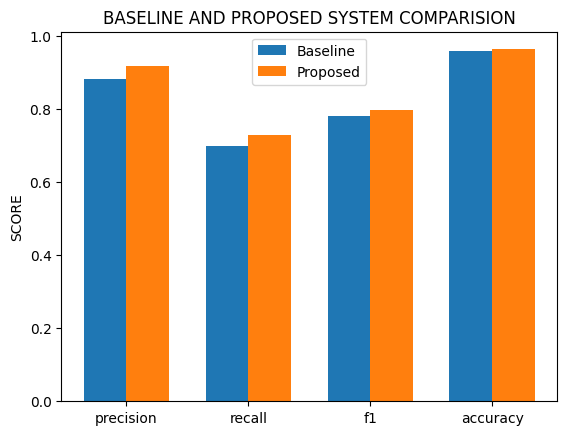

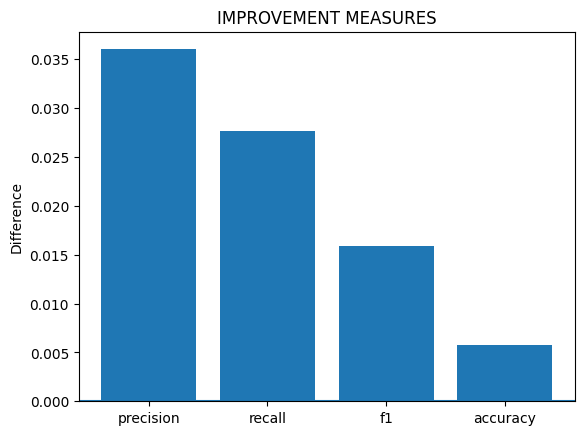

,Metric,Baseline,Proposed,Improvement
0,Precision,0.8838,0.9198,+0.0360
1,Recall,0.7007,0.7283,+0.0276
2,F1,0.7817,0.7976,+0.0159
3,Accuracy,0.9585,0.9643,+0.0057


In [48]:
import json

# LOAD SAVED RESULTS
with open(r"Results/ner_results_conll2003.json", "r") as f:
    results = json.load(f)

# DISPLAY / VISUALIZE
plot_metric_comparison(results)
plot_improvement(results)
show_results_table(results)